In [1]:
import torch
import numpy as np
import logging
import os
from dotenv import load_dotenv

from libs.client import Client, SplitType
from libs.model import ContextAwareActor, ContextAwareCritic, Recommender, RecommenderTrainer

load_dotenv()
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
# ===================== PATHS =====================
USER_ID = "user_55239"
SELECTED_USER_COMPLETE_PATH = f"/mnt/ssd/Carrera/5th_Year/X_SEMESTER/PFC_3/Dataset/processed_users/{USER_ID}_processed.csv"
EMBEDDINGS_CSV_PATH = "/mnt/ssd/Carrera/Datasets/Music4all-Onion/music_4_all_compress_64.csv"
CACHE_PATH = "cache_client.json"
SAVE_PATH = "modelo_recomendacion"

API_URL = os.getenv("API_URL")
EMBEDDING_URL = f"{API_URL}/info"

# ===================== DATA =====================
SPLIT_RATIOS = (0.70, 0.15, 0.15)       # (train, test, validation)
CLIENT_BATCH_SIZE = 32

# ===================== MODEL =====================
EMBEDDING_DIM = 64
HIDDEN_DIM = 256
STATE_DIM = HIDDEN_DIM + 32             # history_rep + context_rep
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ===================== REWARD =====================
REWARD_ALPHA = 0.6                       # weight for interaction_count
REWARD_BETA = 0.4                        # weight for interaction_ratio

# ===================== ACTOR ARCHITECTURE =====================
ACTOR_DROPOUT = 0.1
ACTOR_INIT_GAIN = 1.0                    # was 0.1 — too conservative, caused vanishing gradients
NUM_ATTENTION_HEADS = 4

# ===================== CRITIC ARCHITECTURE =====================
CRITIC_DROPOUT = 0.1
CRITIC_INIT_GAIN = 1.0                   # was 0.01 — too conservative, critic output stuck near zero
CRITIC_OUTPUT_INIT_RANGE = 0.01          # was 0.003 — wider range for output layer
CRITIC_Q_CLAMP = 3.0                     # was 100.0 — with γ=0.1, Q_max≈1.1; clamp at 3× theoretical max

# ===================== DDPG TRAINING =====================
ACTOR_LR = 1e-4                          # was 1e-6 — 1000x too low, actor couldn't learn
CRITIC_LR = 1e-3
ACTOR_WEIGHT_DECAY = 1e-6               # was 1e-4 — too strong relative to old actor LR
CRITIC_WEIGHT_DECAY = 1e-4              # was 1e-6 — critic needs more regularization
GAMMA = 0.1                             # was 0.9 — low gamma keeps Q bounded (Q_max≈1.1), prevents degenerate constant policy
TAU = 0.01                              # was 0.005 — faster target sync with faster learning
BATCH_SIZE = 64                         # replay buffer sample size
STATE_SIZE = 10                          # history window length
MEMORY_CAPACITY = 10_000                 # replay buffer capacity
TARGET_UPDATE_FREQ = 100                 # steps between target network updates
GRAD_CLIP_NORM = 1.0                    # max gradient norm
ACTOR_NOISE_SCALE = 0.1                 # noise scale in actor update
ENTROPY_COEFF = 0.3                     # was 0.01 — must measure cross-batch diversity to prevent mode collapse

# ===================== EXPLORATION =====================
NUM_EPOCHS = 80                          # was 30 — need ~60+ for epsilon to reach 0.05
EPSILON_START = 0.9
EPSILON_END = 0.05                       # was 0.1 — lower floor for more exploitation
EPSILON_DECAY = 0.93                     # was 0.95 — reaches 0.05 in ~45 epochs
EXPLORATION_NOISE = 0.2                  # gaussian noise scale during training
MAX_TRAIN_STEPS = 3000                   # was 1000 — see more diverse items per epoch
MAX_EVAL_STEPS = 1000                    # was 500 — more reliable metric estimates

# ===================== EVALUATION =====================
EVAL_FREQ = 1                            # evaluate every N epochs

print(f"Device: {DEVICE}")
print(f"Epsilon after {NUM_EPOCHS} epochs: {EPSILON_START * EPSILON_DECAY**NUM_EPOCHS:.4f}")

Device: cuda
Epsilon after 80 epochs: 0.0027


In [3]:
def calcular_recompensa_normalizada(interaction_count: int, interaction_ratio: float) -> float:
    """Recompensa acotada entre 0 y 1 para estabilidad."""
    count_factor = np.log1p(interaction_count) / np.log1p(10)
    recompensa = REWARD_ALPHA * count_factor + REWARD_BETA * interaction_ratio
    return float(np.clip(recompensa, 0.0, 1.0))

def ejemplo_get_embedding(track_id: str) -> torch.Tensor:
    import requests
    response = requests.get(f"{EMBEDDING_URL}/{track_id}?info_type=embedding")
    if response.status_code == 200:
        embedding = response.json().get("data", {}).get("embedding", [])
        return torch.tensor(embedding, dtype=torch.float32)
    else:
        logging.error(f"Error al obtener embedding para track_id {track_id}: {response.status_code}")
        return torch.zeros(EMBEDDING_DIM, dtype=torch.float32)

In [4]:
client = Client(
    path=SELECTED_USER_COMPLETE_PATH,
    recompensa_func=calcular_recompensa_normalizada,
    get_embedding_func=ejemplo_get_embedding,
    batch_size=CLIENT_BATCH_SIZE,
    split_ratios=SPLIT_RATIOS,
    cache_path=CACHE_PATH,
    embeddings_path=EMBEDDINGS_CSV_PATH,
)

⏳ Cargando embeddings desde CSV: /mnt/ssd/Carrera/Datasets/Music4all-Onion/music_4_all_compress_64.csv...
✅ 109,262 embeddings cargados exitosamente.

📊 Iniciando procesamiento de 226,609 filas...
💾 Cache inicial: 109,262 embeddings


Procesando datos:   3%|▎         | 5697/226609 [00:00<00:22]

⚠️  Error fila 3301: Invalid URL 'None/info/mrKUj710cpf4eMQZ?info_type=embedding': No scheme supplied. Perhaps you meant ...
⚠️  Error fila 5190: Invalid URL 'None/info/mrKUj710cpf4eMQZ?info_type=embedding': No scheme supplied. Perhaps you meant ...


Procesando datos:   6%|▌         | 12696/226609 [00:01<00:19]

⚠️  Error fila 10315: Invalid URL 'None/info/mrKUj710cpf4eMQZ?info_type=embedding': No scheme supplied. Perhaps you meant ...


...

⚠️  Error fila 46285: Invalid URL 'None/info/mrKUj710cpf4eMQZ?info_type=embedding': No scheme supplied. Perhaps you meant ...


Procesando datos:  23%|██▎       | 51093/226609 [00:04<00:17]

⚠️  Error fila 49219: Invalid URL 'None/info/mrKUj710cpf4eMQZ?info_type=embedding': No scheme supplied. Perhaps you meant ...


Procesando datos: 100%|█████████▉| 226594/226609 [00:21<00:00]


✅ PROCESAMIENTO COMPLETADO - RESUMEN
📈 Estadísticas:
   • Total filas: 226,609
   • Procesadas exitosamente: 226,594 (99.99%)
   • Errores: 15 (0.01%)
   • Cache hits: 226,594 (100.00%)
   • Cache misses: 0 (0.00%)
   • Nuevos embeddings: 0

⏱️  Tiempos:
   • Total: 21.33s (0.36min)
   • Por fila: 0.09ms
   • Velocidad: 10624.3 filas/segundo

💾 Cache final: 109,262 embeddings

⚠️  Se encontraron 15 errores durante el procesamiento
División creada: Train=158615, Test=33989, Validation=33990


In [5]:
actor = ContextAwareActor(
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=ACTOR_DROPOUT,
    init_gain=ACTOR_INIT_GAIN,
    num_heads=NUM_ATTENTION_HEADS,
).to(DEVICE)

critic = ContextAwareCritic(
    state_dim=STATE_DIM,
    action_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=CRITIC_DROPOUT,
    init_gain=CRITIC_INIT_GAIN,
    output_init_range=CRITIC_OUTPUT_INIT_RANGE,
    q_clamp=CRITIC_Q_CLAMP,
).to(DEVICE)

recommender = Recommender(client=client)

recommender_trainer = RecommenderTrainer(
    actor=actor,
    critic=critic,
    client=client,
    recommender=recommender,
    gamma=GAMMA,
    tau=TAU,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    batch_size=BATCH_SIZE,
    state_size=STATE_SIZE,
    device=DEVICE,
    target_update_freq=TARGET_UPDATE_FREQ,
    actor_weight_decay=ACTOR_WEIGHT_DECAY,
    critic_weight_decay=CRITIC_WEIGHT_DECAY,
    memory_capacity=MEMORY_CAPACITY,
    grad_clip_norm=GRAD_CLIP_NORM,
    actor_noise_scale=ACTOR_NOISE_SCALE,
    entropy_coeff=ENTROPY_COEFF,
    max_train_steps=MAX_TRAIN_STEPS,
    max_eval_steps=MAX_EVAL_STEPS,
    exploration_noise=EXPLORATION_NOISE,
)

In [6]:
history = recommender_trainer.train(
    num_epochs=NUM_EPOCHS,
    epsilon_start=EPSILON_START,
    epsilon_end=EPSILON_END,
    epsilon_decay=EPSILON_DECAY,
    eval_freq=EVAL_FREQ,
    save_path=SAVE_PATH,
    push_url="http://localhost:8000/api/epoch"
)

Starting training for 80 epochs in cuda...

Epoch 1/80


Training:   2%|▏         | 52/3000 [00:00<00:33, 88.22it/s]/mnt/ssd/Carrera/5th_Year/X_SEMESTER/PFC_3/Models/actor-critic/library/00_federado/client/to_improve/libs/model.py:217: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  'q1_mean': float(current_q1.mean()),
Training: 100%|██████████| 3000/3000 [00:55<00:00, 53.86it/s]


Train Metrics:
  actor_loss: -0.5434
  critic_loss: 0.0090
  avg_reward: 0.9610
  gt_avg_reward: 0.8768
  reward_ratio: 1.0961
  precision@1: 0.0000
  recall@1: 0.0000
  precision@5: 0.0000
  recall@5: 0.0000
  map@5: 0.0000
  precision@10: 0.1000
  recall@10: 0.1000
  map@10: 0.0111
  ndcg@1: 1.0000
  ndcg@5: 0.9909
  ndcg@10: 0.9620
  context_coverage_days: 1.0000
  context_coverage_hours: 1.0000
  context_coverage_months: 0.7500
  workday_coverage: 1.0000
  temporal_entropy: 0.9843
  context_variety: 0.8889
  embedding_diversity: 14.3116
  cosine_diversity: 0.6996
  div_context_coverage_days: 1.0000
  div_context_coverage_hours: 1.0000
  div_context_coverage_months: 0.7500
  div_workday_coverage: 1.0000
  div_temporal_entropy: 0.9843
  div_context_variety: 0.8889
  novelty_ratio: 0.9400
  rec_length: 100.0000
  gt_length: 100.0000
  rec_reward_mean: 0.9610
  rec_reward_std: 0.0982
  rec_reward_min: 0.4294
  rec_reward_max: 1.0000
  gt_reward_mean: 0.8768
  gt_reward_std: 0.1248
  ex

Training: 100%|██████████| 3000/3000 [00:52<00:00, 57.51it/s]


Train Metrics:
  actor_loss: -0.5922
  critic_loss: 0.0139
  avg_reward: 0.9456
  gt_avg_reward: 0.8768
  reward_ratio: 1.0784
  precision@1: 0.0000
  recall@1: 0.0000
  precision@5: 0.0000
  recall@5: 0.0000
  map@5: 0.0000
  precision@10: 0.1000
  recall@10: 0.1000
  map@10: 0.0167
  ndcg@1: 1.0000
  ndcg@5: 0.9835
  ndcg@10: 0.9640
  context_coverage_days: 1.0000
  context_coverage_hours: 1.0000
  context_coverage_months: 0.7500
  workday_coverage: 1.0000
  temporal_entropy: 0.9803
  context_variety: 0.8889
  embedding_diversity: 13.4840
  cosine_diversity: 0.7057
  div_context_coverage_days: 1.0000
  div_context_coverage_hours: 1.0000
  div_context_coverage_months: 0.7500
  div_workday_coverage: 1.0000
  div_temporal_entropy: 0.9803
  div_context_variety: 0.8889
  novelty_ratio: 0.9700
  rec_length: 100.0000
  gt_length: 100.0000
  rec_reward_mean: 0.9456
  rec_reward_std: 0.1211
  rec_reward_min: 0.3974
  rec_reward_max: 1.0000
  gt_reward_mean: 0.8768
  gt_reward_std: 0.1248
  ex

...

Train Metrics:
  actor_loss: -0.5580
  critic_loss: 0.0199
  avg_reward: 0.9446
  gt_avg_reward: 0.8768
  reward_ratio: 1.0773
  precision@1: 0.0000
  recall@1: 0.0000
  precision@5: 0.0000
  recall@5: 0.0000
  map@5: 0.0000
  precision@10: 0.1000
  recall@10: 0.1000
  map@10: 0.0111
  ndcg@1: 1.0000
  ndcg@5: 0.9372
  ndcg@10: 0.9474
  context_coverage_days: 1.0000
  context_coverage_hours: 1.0000
  context_coverage_months: 0.7500
  workday_coverage: 1.0000
  temporal_entropy: 0.9837
  context_variety: 0.8889
  embedding_diversity: 13.7316
  cosine_diversity: 0.7036
  div_context_coverage_days: 1.0000
  div_context_coverage_hours: 1.0000
  div_context_coverage_months: 0.7500
  div_workday_coverage: 1.0000
  div_temporal_entropy: 0.9837
  div_context_variety: 0.8889
  novelty_ratio: 0.9700
  rec_length: 100.0000
  gt_length: 100.0000
  rec_reward_mean: 0.9446
  rec_reward_std: 0.1255
  rec_reward_min: 0.3749
  rec_reward_max: 1.0000
  gt_reward_mean: 0.8768
  gt_reward_std: 0.1248
  ex

Training: 100%|██████████| 3000/3000 [01:01<00:00, 48.46it/s]


Train Metrics:
  actor_loss: -0.5582
  critic_loss: 0.0196
  avg_reward: 0.9707
  gt_avg_reward: 0.8768
  reward_ratio: 1.1071
  precision@1: 0.0000
  recall@1: 0.0000
  precision@5: 0.0000
  recall@5: 0.0000
  map@5: 0.0000
  precision@10: 0.1000
  recall@10: 0.1000
  map@10: 0.0167
  ndcg@1: 1.0000
  ndcg@5: 0.9664
  ndcg@10: 0.9767
  context_coverage_days: 1.0000
  context_coverage_hours: 1.0000
  context_coverage_months: 0.7500
  workday_coverage: 1.0000
  temporal_entropy: 0.9711
  context_variety: 0.8889
  embedding_diversity: 13.2916
  cosine_diversity: 0.7032
  div_context_coverage_days: 1.0000
  div_context_coverage_hours: 1.0000
  div_context_coverage_months: 0.7500
  div_workday_coverage: 1.0000
  div_temporal_entropy: 0.9711
  div_context_variety: 0.8889
  novelty_ratio: 0.9600
  rec_length: 100.0000
  gt_length: 100.0000
  rec_reward_mean: 0.9707
  rec_reward_std: 0.0679
  rec_reward_min: 0.6749
  rec_reward_max: 1.0000
  gt_reward_mean: 0.8768
  gt_reward_std: 0.1248
  ex

Training: 100%|██████████| 3000/3000 [00:56<00:00, 52.92it/s]


Train Metrics:
  actor_loss: -0.5594
  critic_loss: 0.0200
  avg_reward: 0.9518
  gt_avg_reward: 0.8768
  reward_ratio: 1.0855
  precision@1: 0.0000
  recall@1: 0.0000
  precision@5: 0.0000
  recall@5: 0.0000
  map@5: 0.0000
  precision@10: 0.1000
  recall@10: 0.1000
  map@10: 0.0167
  ndcg@1: 1.0000
  ndcg@5: 0.9578
  ndcg@10: 0.9619
  context_coverage_days: 1.0000
  context_coverage_hours: 1.0000
  context_coverage_months: 0.7500
  workday_coverage: 1.0000
  temporal_entropy: 0.9576
  context_variety: 0.8889
  embedding_diversity: 14.6603
  cosine_diversity: 0.7154
  div_context_coverage_days: 1.0000
  div_context_coverage_hours: 1.0000
  div_context_coverage_months: 0.7500
  div_workday_coverage: 1.0000
  div_temporal_entropy: 0.9576
  div_context_variety: 0.8889
  novelty_ratio: 0.9800
  rec_length: 100.0000
  gt_length: 100.0000
  rec_reward_mean: 0.9518
  rec_reward_std: 0.1236
  rec_reward_min: 0.2574
  rec_reward_max: 1.0000
  gt_reward_mean: 0.8768
  gt_reward_std: 0.1248
  ex

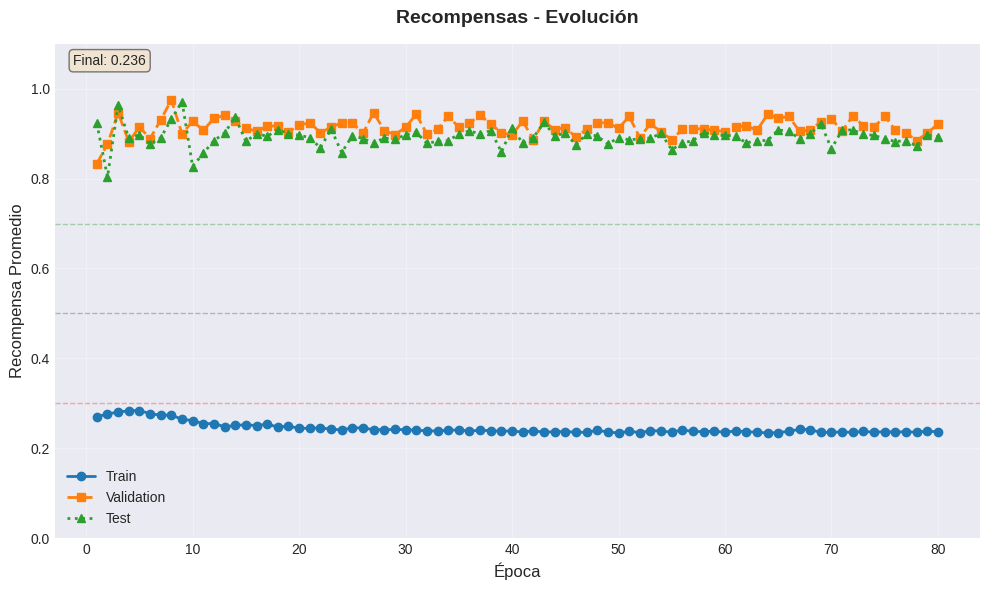

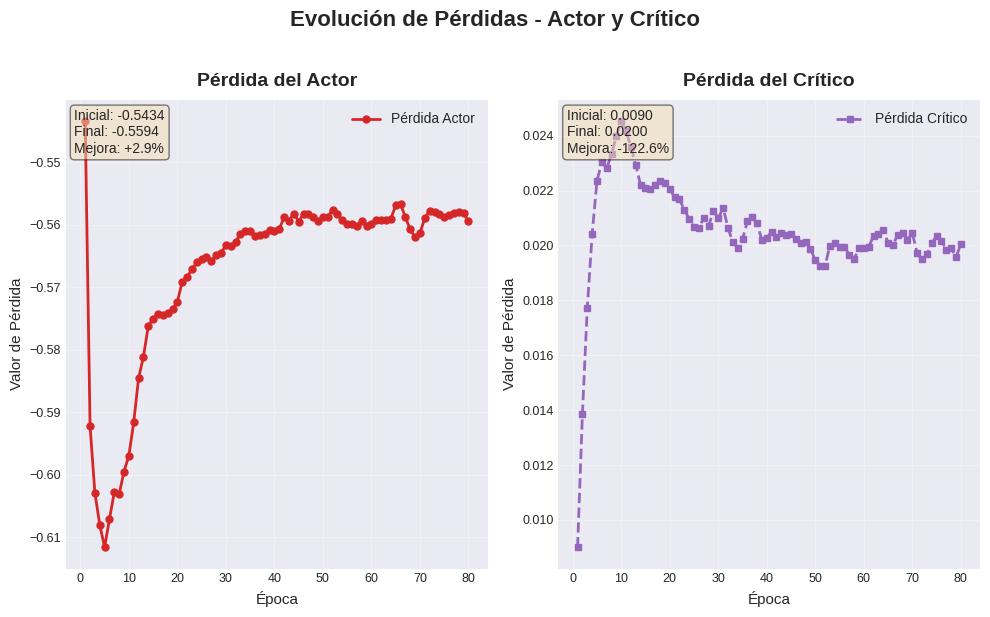

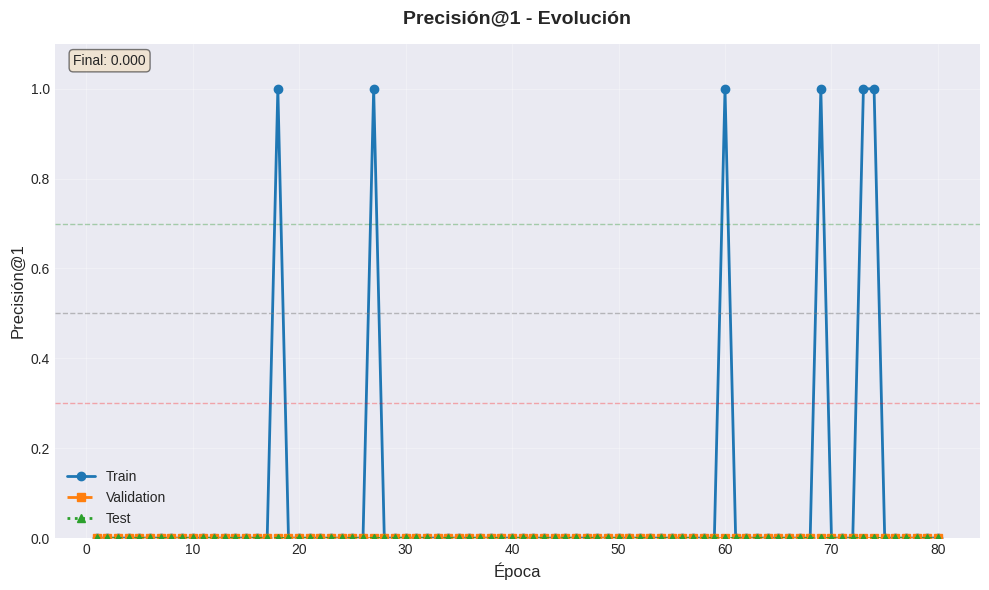

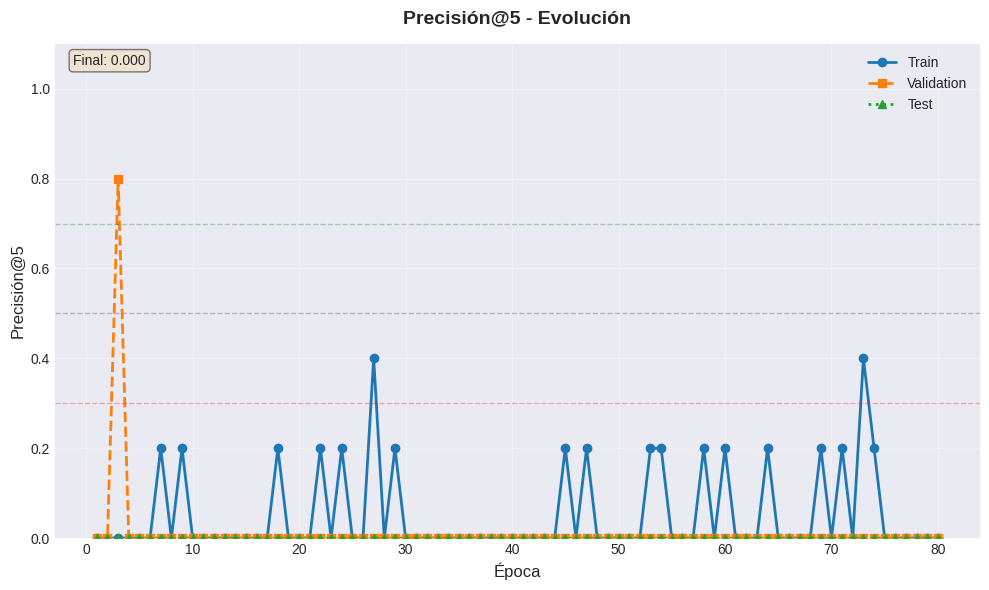

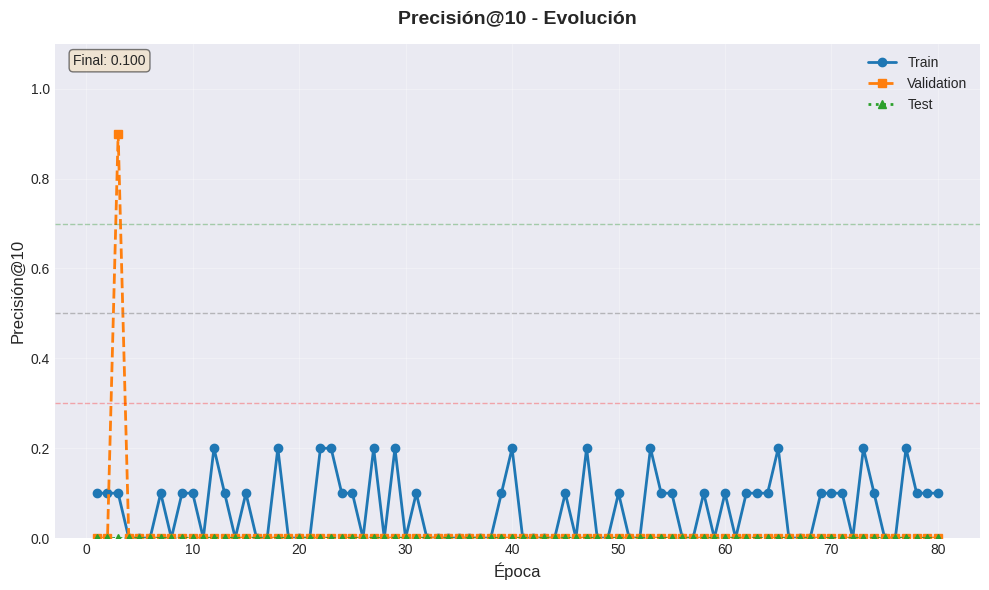

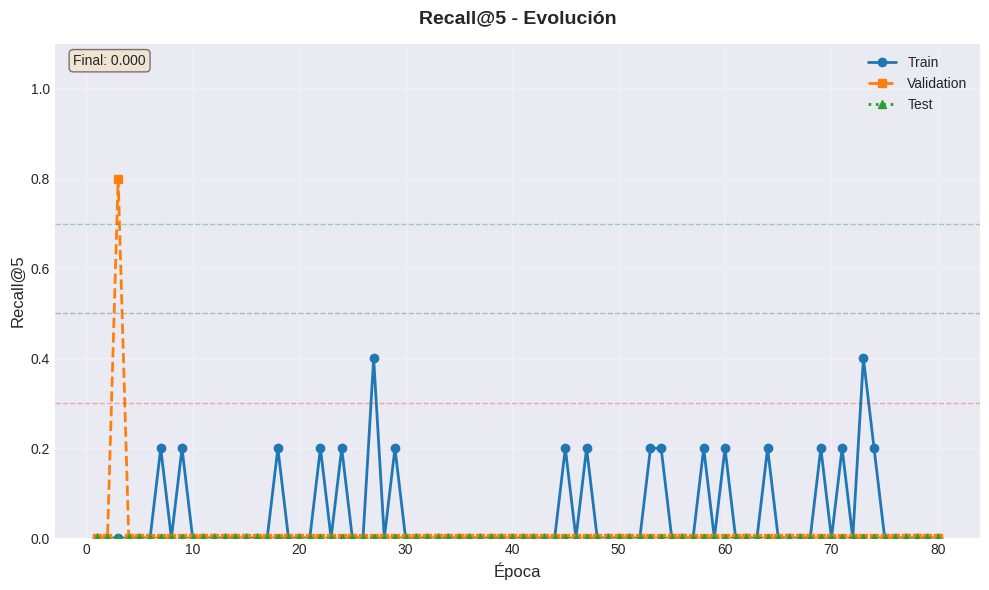

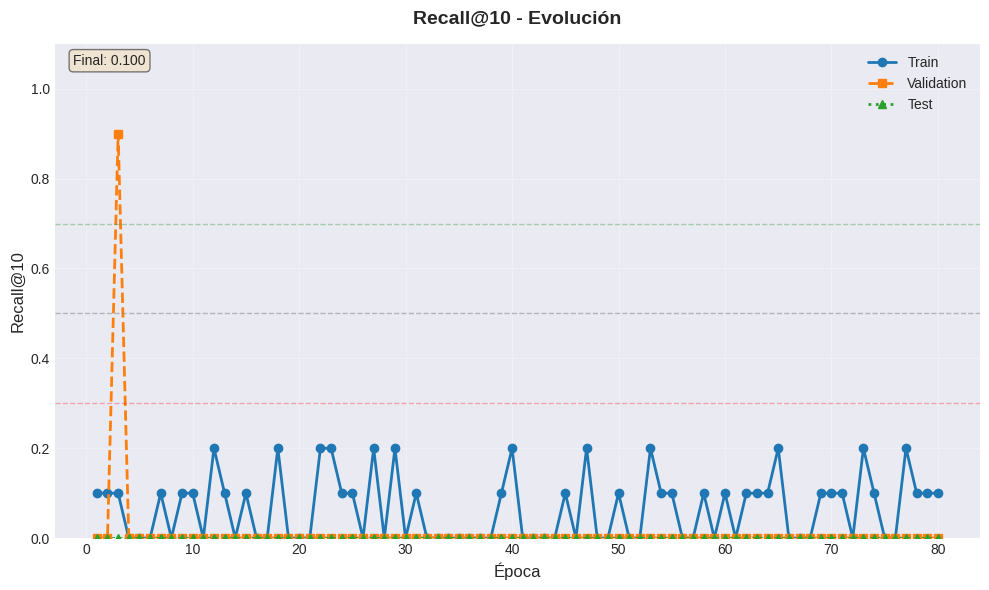

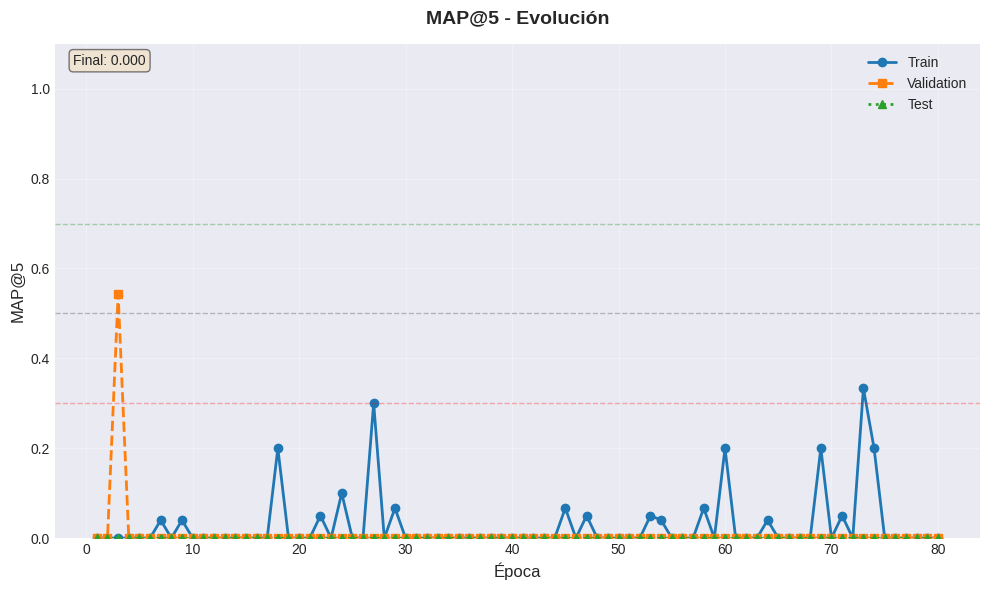

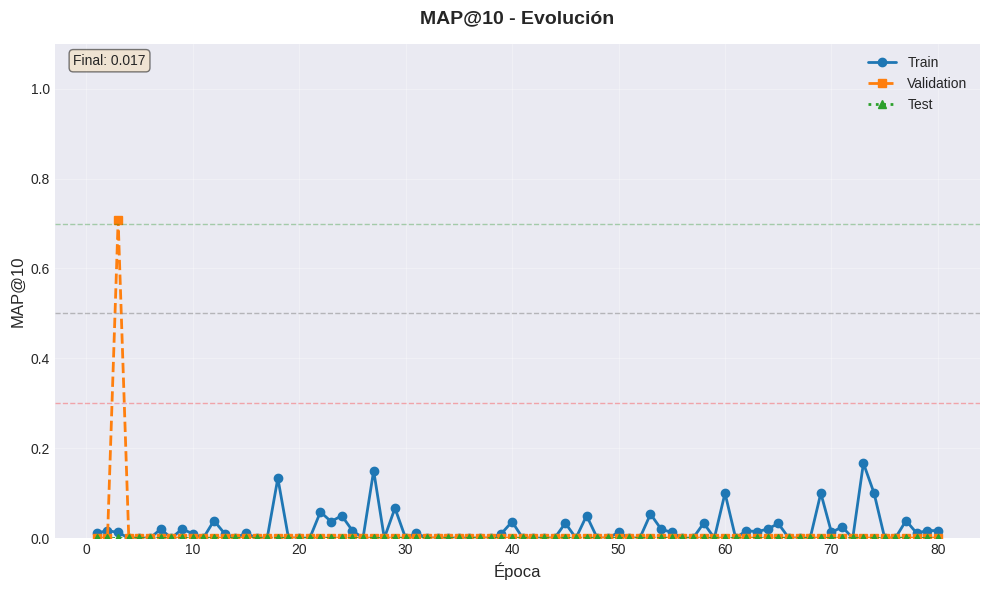

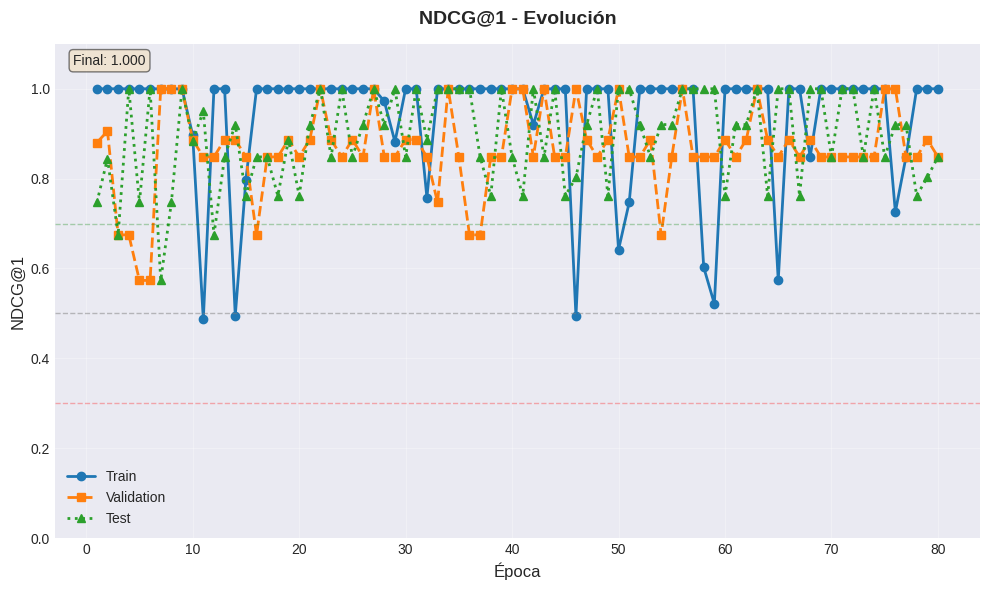

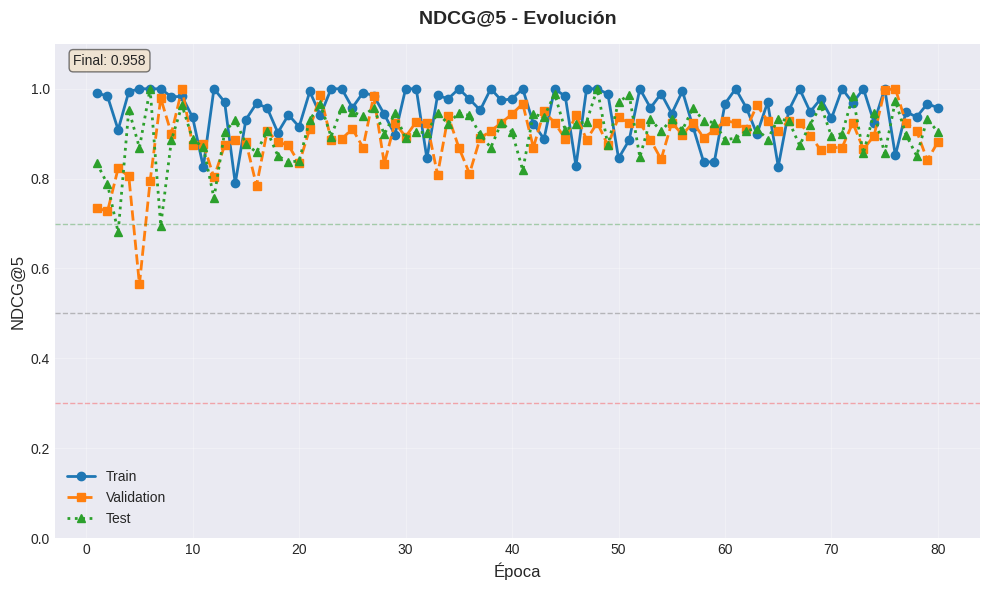

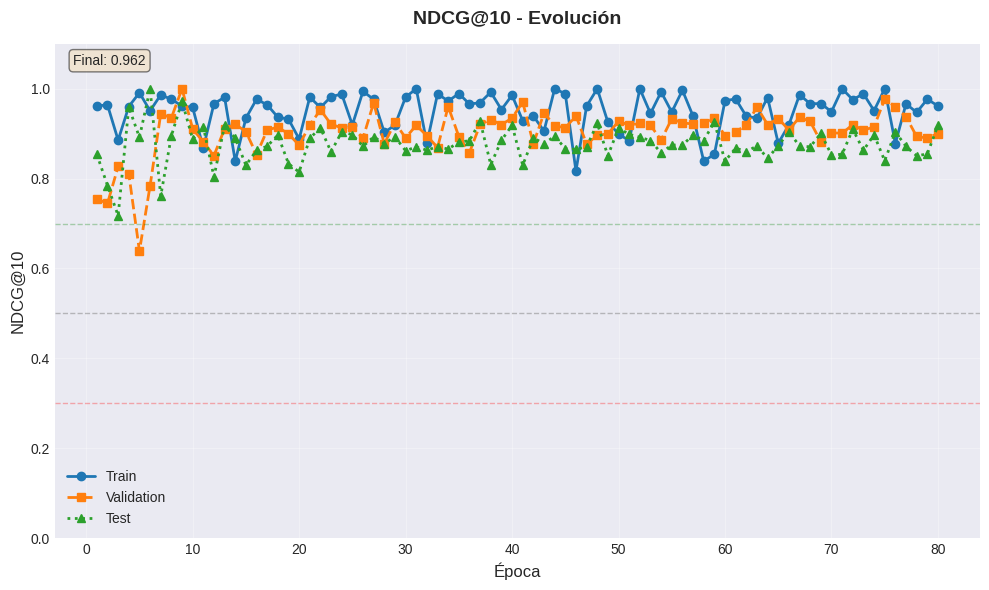

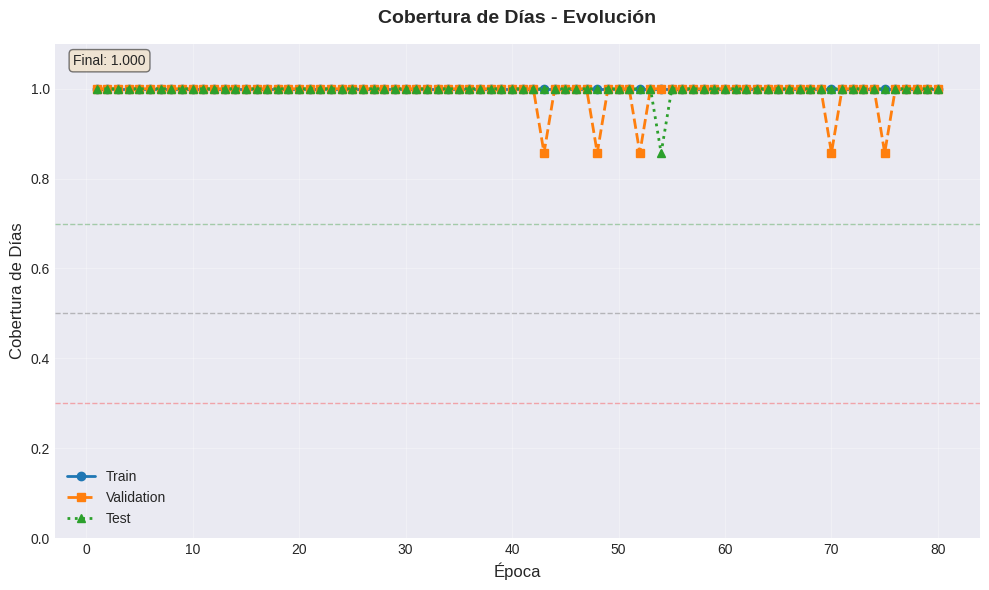

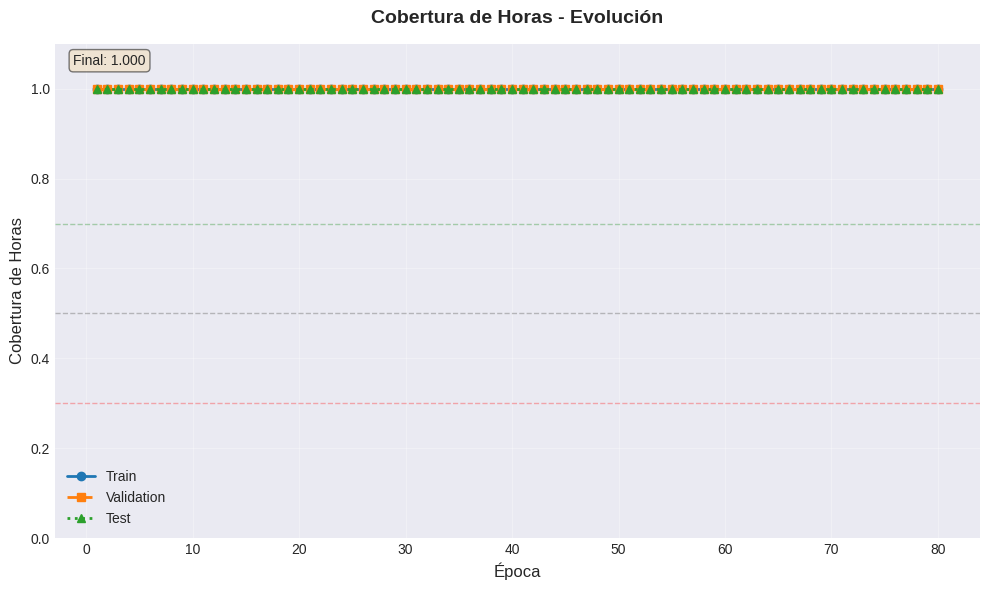

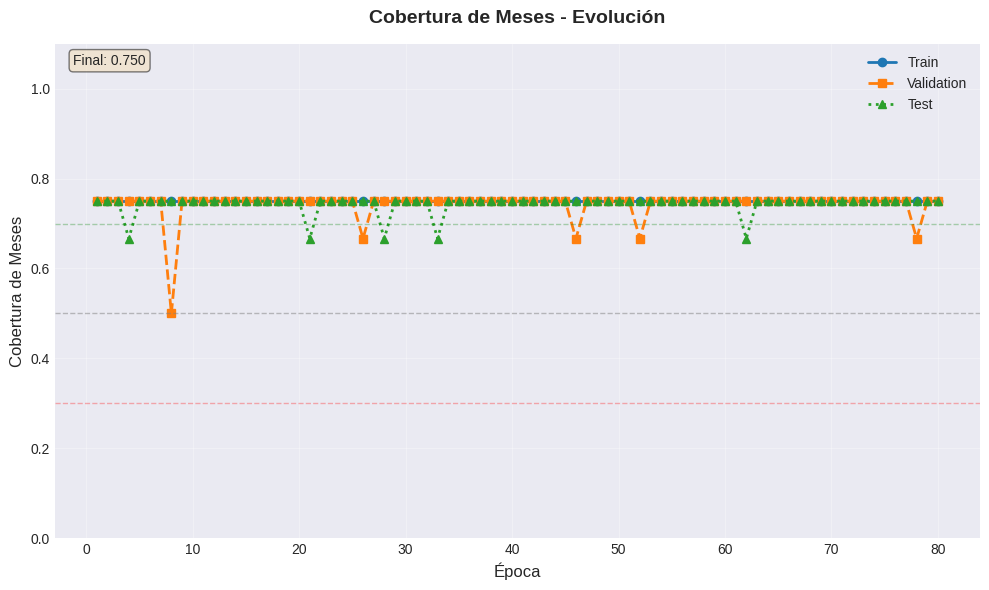

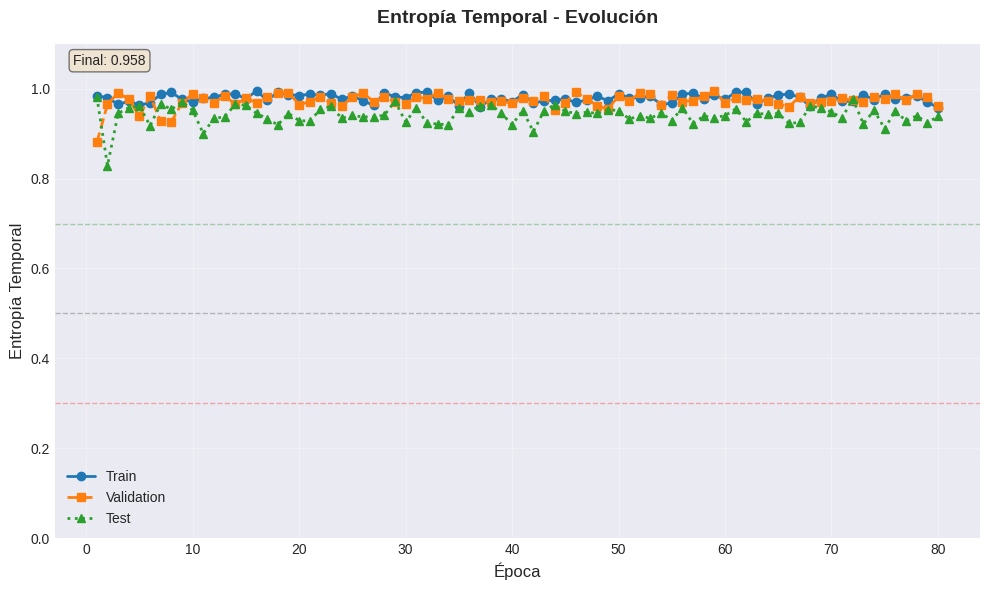

✅ Gráficas individuales creadas


In [7]:
recommender_trainer.plot_individual_metrics()